# Example 1: Coin-toss Hypothesis Testing

## Statistical framework

- **Prior**: $\theta \sim \mathcal B(1/2)$ 
- **Model**: $X \mid \theta \sim \mathcal B(\theta)$ so $p_X(0) = 3/4$, $p_X(1) = 1/4$.
- **Bob's action set**: $B = \{0, 1/2\}$; **Eve's action set**: $E = \{0, 1\}$.
- **Bob's loss** $L_B(x, \delta_B)$ and **Eve's asymmetric 0-1 loss** $L_E(x, \delta_E)$ with parameter $k > 0$ (Eve pays 1 if $(x=0, \delta_E=1)$, $k$ if $(x=1, \delta_E=0)$).
- **Mechanism**: randomized response $q^{(\omega)}$ (1D family) or general joint $p(\eta, X)$ with $\eta = (\delta_B^*, \delta_E^*)$ (2D LP).
- **Alice's objective**: $R_A = R_B - \lambda R_E$; we compare full release, null release, optimal 1D (over $\omega$), and optimal 2D LP.

# Functions

### Setup

In [ ]:

import os
from __future__ import annotations

from dataclasses import dataclass
from itertools import product
from typing import Dict, Tuple, List, Optional

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction



# Set cwd to repo root (parent of notebooks/ when running from notebook)
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    os.chdir(os.path.dirname(_cwd))

os.makedirs("figures/paper", exist_ok=True)
os.makedirs("figures/supplementary", exist_ok=True)
os.makedirs("figures/table", exist_ok=True)

### Plots

In [2]:
def plot_comparison(RA1, RA2, RA3s, omegas, RA4, save_name=None):
    """
    Plot 1D risk curve and (optionally) 2D LP optimum as a horizontal line.
    Also plot RR-push objective if you want to compare "apples-to-apples" with LP objective.
    """


    plt.figure(figsize=(8, 5))
    plt.plot(omegas, RA3s, label=r"Randomized response with $\omega^\star = {0:.2f}$".format(omegas[np.argmin(RA3s)]), color="black")
    # plt.plot(omegas, obj_rr_push, linestyle="--", label=r"RR pushed objective (LP scale)", color="black")

    # Baselines
    plt.axhline(RA1, linestyle="--", color="grey", label=r"(i) Full = (ii) Null $= 1/4$")
    plt.axhline(RA2, linestyle="--", color="grey", alpha=0.7)# label=r"null baseline")

    plt.axhline(RA4, linestyle=":", color="black", label="Linear program optimum")

    plt.xlabel(r"$\omega$", fontsize=14)
    plt.ylabel("$R_A$", fontsize=14)
    # if title is None:
    #     title = rf"Unified comparison (k={k}, lambda={lam:.4g})"
    # plt.title(title)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=300)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Model and mechanisms

#### Full and Null

In [3]:

def RA_full() -> float:
    """Full release baseline: 1/4 (under your convention)."""
    return 0.25


def RA_null(lam: float, k: float) -> float:
    """
    Null release baseline:
      Bob: 1/2
      Eve: min(3/4, k/4)
      => R_A(null) = 1/2 - lam * min(3/4, k/4)
    """
    m = min(0.75, float(k) / 4.0)
    return 0.5 - float(lam) * m

def lambda_equalize_null_full(k: float) -> float:
    """
    Choose lambda such that RA(null)=RA(full)=1/4.
    """
    k = float(k)
    if k <= 0:
        raise ValueError("k must be > 0.")
    m = min(0.75, k / 4.0)
    return 1.0 / (4.0 * m)

#### Randomized Response 

In [4]:

def R_B_rr(omega: float) -> float:
    """
    Bob Bayes risk for randomized response q^(omega):
      R_B(omega) = 1/4 + 1/2 * min(omega, 1-omega)
    """
    omega = float(omega)
    return 0.25 + 0.5 * min(omega, 1.0 - omega)


def R_E_rr(omega: float, k: float) -> float:
    """
    Eve global Bayes risk for RR family under asymmetric loss.

    Piecewise formula (as in your Code 1).
    """
    omega = float(omega)
    k = float(k)
    if not (0.0 <= omega <= 1.0):
        raise ValueError("omega must be in [0,1].")
    if k <= 0.0:
        raise ValueError("k must be > 0.")

    omega0 = 3.0 / (k + 3.0)
    omega1 = k / (k + 3.0)
    a = (k + 3.0) / 4.0  # slope

    if k >= 3.0:
        if omega <= omega0:
            return a * omega
        elif omega <= omega1:
            return 0.75
        else:
            return a * (1.0 - omega)
    else:
        lo, hi = omega1, omega0
        if omega <= lo:
            return a * omega
        elif omega <= hi:
            return k / 4.0
        else:
            return a * (1.0 - omega)

def R_A_rr(omega: float, lam: float, k: float) -> float:
    """
    Alice score for RR family: R_A = R_B - lam * R_E
    """
    return R_B_rr(omega) - float(lam) * R_E_rr(omega, k)

def optimal_rr_omega(omegas : list, lam: float, k: float) -> float:
    """
    Compute the optimal omega for the RR family.
    """
    RAs_rr = [R_A_rr(omega, lam, k) for omega in omegas]
    return RAs_rr, omegas[np.argmin(RAs_rr)], np.min(RAs_rr)



#### Linear Programming optimization

In [5]:
@dataclass(frozen=True)
class CoinTossBAPModel:
    """
    Discrete toy model:
      X in {0,1} with pX = {0:3/4, 1:1/4}
      Bob action set B = {0, 1/2}
      Eve action set E = {0, 1}
    """
    k: float  # Eve's asymmetry parameter (>0)

    # Action spaces
    X: Tuple[int, int] = (0, 1)
    B: Tuple[float, float] = (0.0, 0.5)
    E: Tuple[int, int] = (0, 1)

    def pX(self) -> Dict[int, float]:
        return {0: 3.0 / 4.0, 1: 1.0 / 4.0}

    def LB(self) -> Dict[Tuple[int, float], float]:
        """
        Bob integrated loss L_B(x, delta_B):
        (copied from your LP code)
        """
        return {
            (0, 0.0): 1.0 / 3.0,
            (0, 0.5): 2.0 / 3.0,
            (1, 0.0): 1.0,
            (1, 0.5): 0.0,
        }

    def LE(self) -> Dict[Tuple[int, int], float]:
        """
        Eve asymmetric 0-1 loss:
          0 if correct,
          1 if (x=0, delta=1),
          k if (x=1, delta=0).
        """
        k = float(self.k)
        return {
            (0, 0): 0.0,
            (0, 1): 1.0,
            (1, 0): k,
            (1, 1): 0.0,
        }


def solve_general_lp(
    model: CoinTossBAPModel,
    lam: float,
    solver_msg: bool = False,
) -> Dict[str, object]:
    """
    Solve the 2D LP over p_{ij}^k = P(X=k, eta=(i,j)) with Bayes-optimality constraints
    (as in your Code 2), for a fixed lambda.

    Returns:
      objective, p_ij^k, q(eta|x), p(eta), p(x|eta)
    """
    import pulp  # local import so file still runs without PuLP if you skip LP

    lam = float(lam)
    if lam < 0:
        raise ValueError("lam must be >= 0.")

    X = list(model.X)
    B = list(model.B)
    E = list(model.E)
    pX = model.pX()
    LB = model.LB()
    LE = model.LE()

    prob = pulp.LpProblem("BAP_GeneralLP", pulp.LpMinimize)

    p = pulp.LpVariable.dicts(
        "p",
        ((x, i, j) for x, i, j in product(X, B, E)),
        lowBound=0.0,
        cat="Continuous",
    )

    # Marginals: sum_{i,j} p(x,i,j) = pX[x]
    for x in X:
        prob += pulp.lpSum(p[(x, i, j)] for i, j in product(B, E)) == pX[x], f"marginal_X_{x}"

    # Bayes-optimality constraints for Bob given eta=(i,j)
    for i, j in product(B, E):
        for l in B:
            if l == i:
                continue
            prob += (
                pulp.lpSum(LB[(x, i)] * p[(x, i, j)] for x in X)
                <=
                pulp.lpSum(LB[(x, l)] * p[(x, i, j)] for x in X)
            ), f"bob_opt_eta_{i}_{j}_vs_{l}"

    # Bayes-optimality constraints for Eve given eta=(i,j)
    for i, j in product(B, E):
        for l in E:
            if l == j:
                continue
            prob += (
                pulp.lpSum(LE[(x, j)] * p[(x, i, j)] for x in X)
                <=
                pulp.lpSum(LE[(x, l)] * p[(x, i, j)] for x in X)
            ), f"eve_opt_eta_{i}_{j}_vs_{l}"

    # Objective: E[ LB(X,i) - lam * LE(X,j) ]
    prob += pulp.lpSum(
        (LB[(x, i)] - lam * LE[(x, j)]) * p[(x, i, j)]
        for x, i, j in product(X, B, E)
    ), "alice_objective"

    solver = pulp.PULP_CBC_CMD(msg=solver_msg)
    status = prob.solve(solver)
    if pulp.LpStatus[status] != "Optimal":
        raise RuntimeError(f"LP did not solve to optimality. Status={pulp.LpStatus[status]}")

    p_sol = {(x, i, j): float(pulp.value(p[(x, i, j)])) for x, i, j in product(X, B, E)}

    # q(eta|x) = p(x,eta)/pX[x]
    q_eta_given_x = {(x, i, j): p_sol[(x, i, j)] / pX[x] for x, i, j in product(X, B, E)}

    # p(eta)
    p_eta = {(i, j): sum(p_sol[(x, i, j)] for x in X) for i, j in product(B, E)}

    # p(x|eta)
    p_x_given_eta = {}
    for i, j in product(B, E):
        denom = p_eta[(i, j)]
        for x in X:
            p_x_given_eta[(x, i, j)] = (p_sol[(x, i, j)] / denom) if denom > 0 else None

    obj = float(pulp.value(prob.objective))

    return {
        "objective": obj,
        "p_xij": p_sol,
        "q_eta_given_x": q_eta_given_x,
        "p_eta": p_eta,
        "p_x_given_eta": p_x_given_eta,
        "lambda": lam,
        "k": model.k,
    }

## Run

In [10]:
k = 10.0
lam = lambda_equalize_null_full(k)

RA1 = RA_full()
RA2 = RA_null(lam, k)
print("Lambda: ", lam)
print("(i) Full = (ii) Null: ", RA1, RA2)

omegas = np.linspace(0, 1, 100)
RA3s, omega_rr, RA3 = optimal_rr_omega(omegas, lam, k)
print("(iii) Randomized response: ", RA3, omega_rr)

lp_res = solve_general_lp(CoinTossBAPModel(k=k), lam=lam, solver_msg=False)
RA4 = lp_res["objective"]
print("(iv) Linear program optimum: ", RA4)
print("Nonzero q(eta|x) (threshold 1e-10):")
for (x, i, j), val in lp_res["q_eta_given_x"].items():
    if val > 1e-10:
        print(f"  x={x}, eta=(i={i}, j={j}) : {val:.1f}")

Lambda:  0.3333333333333333
(i) Full = (ii) Null:  0.25 0.25
(iii) Randomized response:  0.11616161616161613 0.7676767676767677
(iv) Linear program optimum:  0.07499999999999996
Nonzero q(eta|x) (threshold 1e-10):
  x=0, eta=(i=0.0, j=1) : 1.0
  x=1, eta=(i=0.0, j=1) : 0.3
  x=1, eta=(i=0.5, j=1) : 0.7


## Plot

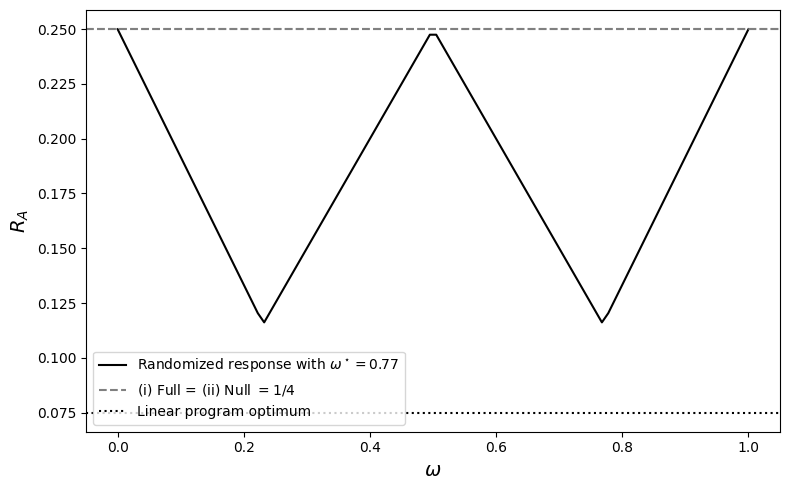

In [7]:
plot_comparison(RA1, RA2, RA3s, omegas, RA4, save_name="figures/paper/plot_cointoss.pdf")

## Save table results

In [8]:
def _tex_frac(x: float, max_den: int = 500) -> str:
    frac = Fraction(x).limit_denominator(max_den)
    return rf"\tfrac{{{frac.numerator}}}{{{frac.denominator}}}"

def write_coin_table_tex(
    RA1: float,
    RA2: float,
    lamb: float,
    RA3s,
    omegas,
    lp_res: dict,
    save_name: str,
    decimals: int = 2,

    RB1: float = None, RE1: float = 0.0,
    RB2: float = 0.50, RE2: float = 0.75,
    RE4: float = 0.75,
):
    """
    Build + print + save LaTeX table for coin-toss summary.

    Inputs:
      - RA1, RA2: integrated risks for Full / Null (already computed)
      - lamb: calibrated lambda
      - RA3s: array-like of RA values for RR over `omegas`
      - omegas: array-like grid corresponding to RA3s
      - lp_res: dict with at least {'objective', 'k', 'lambda'}
      - save_name: filename (without extension) saved to tables/<save_name>.tex

    Output:
      - returns the LaTeX string
    """
    RA1 = float(RA1)
    RA2 = float(RA2)
    lamb = float(lamb)

    RA3s = np.asarray(RA3s, dtype=float)
    omegas = np.asarray(omegas, dtype=float)
    if RA3s.shape != omegas.shape:
        raise ValueError("RA3s and omegas must have the same shape.")

    # RR optimum on the provided grid
    idx3 = int(np.argmin(RA3s))
    omega_star = float(omegas[idx3])
    RA3 = float(RA3s[idx3])

    # Infer/compute RR RB/RE
    k = float(lp_res.get("k", np.nan))
    if np.isnan(k):
        raise ValueError("lp_res must contain key 'k' (used to compute R_E_rr).")

    RB3 = float(R_B_rr(omega_star))
    RE3 = float(R_E_rr(omega_star, k))

    # LP optimum
    RA4 = float(lp_res["objective"])
    # If RE4 is fixed (as in your example), infer RB4 from RA4 = RB4 - lambda*RE4
    RB4 = RA4 + lamb * RE4

    # Full/Null RB values
    if RB1 is None:
        RB1 = RA1  # since RE1=0 by convention in your example

    # Pretty omega* display (optional): analytic candidates 3/(k+3) and k/(k+3)
    omega0 = 3.0 / (k + 3.0)
    omega1 = k / (k + 3.0)
    omega_star_tex = rf"{_tex_frac(omega0)} or {_tex_frac(omega1)}"


    fmt = lambda x: f"{x:.{decimals}f}"

    latex = []

    latex.append(r"Mechanism & $R_B$ & $R_E$ & $R_A$\\")
    latex.append(r"\hline")
    latex.append(rf"Full & {fmt(RB1)} & {fmt(RE1)} & {fmt(RA1)} \\")
    latex.append(rf"Null  & {fmt(RB2)} & {fmt(RE2)} & {fmt(RA2)} \\")
    latex.append(rf"Randomised ($\omega^\star = {omega_star_tex}$) & {fmt(RB3)} & {fmt(RE3)} & {fmt(RA3)} \\")
    latex.append(rf"Linear-program optimum & {fmt(RB4)} & {fmt(RE4)} & {fmt(RA4)}")
    latex_str = "\n".join(latex) + "\n"

    # Print to notebook
    print(latex_str)

    # Save
    out_path = os.path.join(f"{save_name}")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(latex_str)

    return latex_str

_ = write_coin_table_tex(RA1, RA2, lam, RA3s, omegas, lp_res, save_name="tables/cointoss_table.tex")

Mechanism & $R_B$ & $R_E$ & $R_A$\\
\hline
Full & 0.25 & 0.00 & 0.25 \\
Null  & 0.50 & 0.75 & 0.25 \\
Randomised ($\omega^\star = \tfrac{3}{13} or \tfrac{10}{13}$) & 0.37 & 0.75 & 0.12 \\
Linear-program optimum & 0.32 & 0.75 & 0.07

